# Optuna Hyperparameter Optimization — Gradient Boosting Classification


Tunes the `GradientBoostingClassifier` used in the "Classification" recommender from `model_comparasion_270day_metrics_updated_threshold_070.ipynb`, using the same 270-day temporal holdout and the **same full metric suite** as that notebook's final comparison table (Precision, Recall, Hit Rate, Long-tail Precision/Recall/Hit Rate/Share/Catalog Coverage, NDCG, MAP, Average Score, Sparsity).


## 1. Imports


In [ ]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from reactiva.config import DATASET_URI


c:\henrylocal\FP_MODULE\FP_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data + 270-Day Holdout Split
Identical split to the model comparison notebook.


In [2]:
df = pd.read_csv(DATASET_URI)
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

MAX_DATE = df['Purchase Date'].max()
CUTOFF = MAX_DATE - pd.Timedelta(days=270)

df_train = df[df['Purchase Date'] < CUTOFF].copy()
df_holdout = df[df['Purchase Date'] >= CUTOFF].copy()

train_customers = df_train['Customer ID'].unique()
holdout_customers = df_holdout['Customer ID'].unique()
scoring_customers = np.intersect1d(train_customers, holdout_customers)

print(f'Latest purchase date: {MAX_DATE.date()}')
print(f'Cutoff date: {CUTOFF.date()}')
print(f'Train rows (older than cutoff): {len(df_train)}')
print(f'Holdout rows (last 270 days): {len(df_holdout)}')
print(f'Scoring customers: {len(scoring_customers)}')


Latest purchase date: 2024-12-30
Cutoff date: 2024-04-04
Train rows (older than cutoff): 6281
Holdout rows (last 270 days): 3719
Scoring customers: 1877


## 3. Shared Metric Helpers
Same helper functions as the original notebook — precision/recall/hit rate, NDCG, MAP, long-tail definitions and metrics, and sparsity — so results are directly comparable to the original comparison table.


In [3]:
def precision_recall_at_k(recommended, actual, k):
    rec_k = list(recommended[:k])
    actual = set(actual)
    if not rec_k:
        return 0.0, 0.0, 0.0

    hits = len(set(rec_k) & actual)
    precision = hits / len(rec_k)
    recall = hits / len(actual) if actual else 0.0
    hit_rate = float(hits > 0)

    return precision, recall, hit_rate


def ndcg_at_k(recommended, actual, k):
    """Binary NDCG@K: correct/relevant items receive relevance=1."""
    rec_k = list(recommended[:k])
    actual = set(actual)
    if not rec_k or not actual:
        return 0.0

    dcg = 0.0
    for rank, item in enumerate(rec_k, start=1):
        if item in actual:
            dcg += 1.0 / np.log2(rank + 1)

    ideal_hits = min(len(actual), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    return dcg / idcg if idcg else 0.0


def average_precision_at_k(recommended, actual, k):
    """Average Precision@K for binary relevance."""
    rec_k = list(recommended[:k])
    actual = set(actual)
    if not rec_k or not actual:
        return 0.0

    hits = 0
    precision_sum = 0.0
    seen = set()

    for rank, item in enumerate(rec_k, start=1):
        if item in actual and item not in seen:
            seen.add(item)
            hits += 1
            precision_sum += hits / rank

    return precision_sum / min(len(actual), k) if min(len(actual), k) else 0.0


def long_tail_sets(df_train, cumulative_cutoff=0.8):
    """Define head/tail from training popularity only, avoiding holdout leakage."""
    counts = df_train['Item Purchased'].value_counts()
    cum_share = counts.cumsum() / counts.sum()
    head_items = set(cum_share[cum_share <= cumulative_cutoff].index)

    if not head_items and len(counts):
        head_items = {counts.index[0]}

    tail_items = set(counts.index) - head_items
    return head_items, tail_items


def long_tail_metrics(recommended, actual, tail_items, k):
    """Customer-level long-tail precision/recall/hit rate."""
    rec_k = list(recommended[:k])
    actual_tail = set(actual) & tail_items
    recommended_tail = set(rec_k) & tail_items
    hits = len(recommended_tail & actual_tail)

    long_tail_precision = hits / len(recommended_tail) if recommended_tail else 0.0
    long_tail_recall = hits / len(actual_tail) if actual_tail else np.nan
    long_tail_hit_rate = float(hits > 0) if actual_tail else np.nan

    return long_tail_precision, long_tail_recall, long_tail_hit_rate


def get_result_columns(results_df):
    """Resolve recommendation/actual columns while preserving each model's existing names."""
    recommendation_candidates = ['recommended', 'Recommendations', 'recommendations']
    actual_candidates = ['actual', 'Actual', 'Actual Items']

    recommendation_col = next(
        (column for column in recommendation_candidates if column in results_df.columns), None
    )
    actual_col = next(
        (column for column in actual_candidates if column in results_df.columns), None
    )

    if recommendation_col is None or actual_col is None:
        raise ValueError('Could not identify recommendation/actual columns in results dataframe.')

    return recommendation_col, actual_col


def calculate_all_ranking_and_long_tail_metrics(results_df, df_train, k=5, cumulative_cutoff=0.8):
    """Calculate ranking and long-tail metrics from stored recommendations/actuals."""
    if results_df.empty:
        return {
            'Precision': np.nan, 'Recall': np.nan, 'Hit Rate': np.nan,
            'NDCG': np.nan, 'MAP': np.nan,
            'Long-tail Precision': np.nan, 'Long-tail Recall': np.nan,
            'Long-tail Hit Rate': np.nan, 'Long-tail Share': np.nan,
            'Long-tail Catalog Coverage': np.nan
        }

    recommendation_col, actual_col = get_result_columns(results_df)
    _, tail_items = long_tail_sets(df_train, cumulative_cutoff=cumulative_cutoff)

    precision_values, recall_values, hit_values = [], [], []
    ndcg_values, map_values = [], []
    tail_precision_values, tail_recall_values, tail_hit_values = [], [], []
    all_recommended_items = []

    for _, row in results_df.iterrows():
        recommended = row[recommendation_col] or []
        actual = row[actual_col] or []

        precision, recall, hit_rate = precision_recall_at_k(recommended, actual, k)
        precision_values.append(precision)
        recall_values.append(recall)
        hit_values.append(hit_rate)
        ndcg_values.append(ndcg_at_k(recommended, actual, k))
        map_values.append(average_precision_at_k(recommended, actual, k))

        tail_precision, tail_recall, tail_hit = long_tail_metrics(recommended, actual, tail_items, k)
        tail_precision_values.append(tail_precision)
        tail_recall_values.append(tail_recall)
        tail_hit_values.append(tail_hit)

        all_recommended_items.extend(list(recommended[:k]))

    recommendation_denominator = len(all_recommended_items)
    tail_recommendation_count = sum(1 for item in all_recommended_items if item in tail_items)
    long_tail_share = (
        tail_recommendation_count / recommendation_denominator if recommendation_denominator else 0.0
    )

    distinct_tail_recommended = {item for item in all_recommended_items if item in tail_items}
    long_tail_catalog_coverage = (
        len(distinct_tail_recommended) / len(tail_items) if tail_items else 0.0
    )

    return {
        'Precision': np.mean(precision_values),
        'Recall': np.mean(recall_values),
        'Hit Rate': np.mean(hit_values),
        'NDCG': np.mean(ndcg_values),
        'MAP': np.mean(map_values),
        'Long-tail Precision': np.mean(tail_precision_values),
        'Long-tail Recall': np.nanmean(tail_recall_values),
        'Long-tail Hit Rate': np.nanmean(tail_hit_values),
        'Long-tail Share': long_tail_share,
        'Long-tail Catalog Coverage': long_tail_catalog_coverage
    }


def sparsity_of_matrix(user_item_matrix):
    total_cells = user_item_matrix.size
    if total_cells == 0:
        return np.nan
    nonzero_cells = (user_item_matrix.values > 0).sum()
    return 1 - (nonzero_cells / total_cells)


## 4. Customer Features
Same feature set as the original notebook: per-category purchase counts, total purchases, and days since last purchase.


In [4]:
def build_customer_features(df_train):
    cat_counts = df_train.pivot_table(
        index='Customer ID',
        columns='Category',
        values='Item Purchased',
        aggfunc='count',
        fill_value=0
    )
    cat_counts.columns = [f'cat_count_{c}' for c in cat_counts.columns]

    agg = df_train.groupby('Customer ID').agg(
        total_purchases=('Item Purchased', 'count'),
        last_purchase=('Purchase Date', 'max')
    )

    reference_date = df_train['Purchase Date'].max()
    agg['days_since_last_purchase'] = (reference_date - agg['last_purchase']).dt.days
    agg = agg.drop(columns='last_purchase')

    return cat_counts.join(agg, how='inner')


## 5. Build X / y and the Fixed Train/Test Split
Built once, outside the objective function, so every Optuna trial evaluates on the exact same split (only the classifier's hyperparameters change between trials).


In [5]:
K = 5
TEST_SIZE = 0.3
RANDOM_STATE = 42
TAIL_CUMULATIVE_CUTOFF = 0.8

features = build_customer_features(df_train)
features = features.loc[features.index.isin(scoring_customers)]

labels = (
    df_holdout[df_holdout['Customer ID'].isin(features.index)]
    .groupby('Customer ID')['Category']
    .agg(lambda x: x.mode().iloc[0])
)

X = features
y = labels.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

item_pop_by_cat = (
    df_train.groupby(['Category', 'Item Purchased'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

actuals_by_user = {
    user: set(df_holdout[df_holdout['Customer ID'] == user]['Item Purchased'])
    for user in X_test.index
}

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (1313, 5), X_test: (564, 5)


## 6. Evaluation Function — Full Metric Suite
Predicts each test customer's category, recommends the top-K most popular items in that category (trained on `df_train` only), builds a results dataframe in the same shape as the original notebook's `results_classification`, then runs it through `calculate_all_ranking_and_long_tail_metrics` plus sparsity — giving the exact same 12 columns as the original notebook's final comparison table.


In [6]:
def evaluate_classifier(clf, model_name='Classification', k=K):
    pred_category = pd.Series(clf.predict(X_test), index=X_test.index)

    recommendation_results = []
    for user in X_test.index:
        cat = pred_category[user]
        top_items = (
            item_pop_by_cat[item_pop_by_cat['Category'] == cat]['Item Purchased']
            .head(k)
            .tolist()
        )
        actual = actuals_by_user[user]

        recommendation_results.append({
            'Customer ID': user,
            'Predicted Category': cat,
            'Recommendations': top_items,
            'Actual Items': list(actual),
        })

    results_df = pd.DataFrame(recommendation_results)

    metrics = calculate_all_ranking_and_long_tail_metrics(
        results_df, df_train, k=k, cumulative_cutoff=TAIL_CUMULATIVE_CUTOFF
    )

    sparsity = sparsity_of_matrix(
        pd.crosstab(df_train['Customer ID'], df_train['Item Purchased'])
    )

    performance_columns = [
        'Precision', 'Recall', 'Hit Rate',
        'Long-tail Precision', 'Long-tail Recall', 'Long-tail Hit Rate',
        'NDCG', 'MAP'
    ]

    row = {
        'Model': model_name,
        **metrics,
        'Average Score': np.nanmean([metrics[c] for c in performance_columns]),
        'Sparsity': sparsity
    }

    column_order = [
        'Model', 'Precision', 'Recall', 'Hit Rate',
        'Long-tail Precision', 'Long-tail Recall', 'Long-tail Hit Rate',
        'Long-tail Share', 'Long-tail Catalog Coverage',
        'NDCG', 'MAP', 'Average Score', 'Sparsity'
    ]

    return pd.Series(row)[column_order], results_df


## 7. Baseline (Untuned) Gradient Boosting
Same as the original notebook's `Classification` row, for comparison.


In [7]:
baseline_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
baseline_clf.fit(X_train, y_train)
baseline_row, baseline_results_df = evaluate_classifier(
    baseline_clf, model_name='Classification (baseline)'
)

display(baseline_row.to_frame().T.round(4))


,Model,Precision,Recall,Hit Rate,Long-tail Precision,Long-tail Recall,Long-tail Hit Rate,Long-tail Share,Long-tail Catalog Coverage,NDCG,MAP,Average Score,Sparsity
0,Classification (baseline),0.107801,0.341844,0.468085,0.00133,0.017544,0.017544,0.022695,0.444444,0.237117,0.176979,0.171031,0.914113


## 8. Optuna Objective
Searches `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_split`, `min_samples_leaf`, and `max_features`. Maximizes Precision@K on the holdout (matching what the original notebook reports as the headline metric); the full metric suite is recomputed afterward for the best trial.


In [8]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=25),
        'max_depth': trial.suggest_int('max_depth', 1, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': RANDOM_STATE,
    }

    clf = GradientBoostingClassifier(**params)
    clf.fit(X_train, y_train)

    row, _ = evaluate_classifier(clf)
    trial.set_user_attr('recall', row['Recall'])
    trial.set_user_attr('hit_rate', row['Hit Rate'])

    return row['Precision']


## 9. Run the Study


In [9]:
N_TRIALS = 100

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('\n=== Best trial ===')
print(f"Precision@{K}: {study.best_value:.4f}")
print(f"Recall@{K}:    {study.best_trial.user_attrs['recall']:.4f}")
print(f"HitRate@{K}:   {study.best_trial.user_attrs['hit_rate']:.4f}")
print('Best params:')
for name, value in study.best_params.items():
    print(f'  {name}: {value}')


[I 2026-08-23 05:44:55,004] A new study created in memory with name: no-name-80344fad-8a3a-43a6-96a3-da218e42256f
Best trial: 0. Best value: 0.0989362:   1%|          | 1/100 [00:05<09:18,  5.64s/it]

[I 2026-08-23 05:45:00,651] Trial 0 finished with value: 0.09893617021276595 and parameters: {'n_estimators': 225, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.09893617021276595.


Best trial: 1. Best value: 0.109574:   2%|▏         | 2/100 [00:08<06:25,  3.93s/it] 

[I 2026-08-23 05:45:03,381] Trial 1 finished with value: 0.10957446808510637 and parameters: {'n_estimators': 375, 'max_depth': 1, 'learning_rate': 0.2708160864249968, 'subsample': 0.9162213204002109, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 0.10957446808510637.


Best trial: 1. Best value: 0.109574:   3%|▎         | 3/100 [00:11<05:24,  3.34s/it]

...

[I 2026-08-23 05:47:17,625] Trial 97 finished with value: 0.11063829787234043 and parameters: {'n_estimators': 450, 'max_depth': 2, 'learning_rate': 0.0650392065062952, 'subsample': 0.7536828689306273, 'min_samples_split': 5, 'min_samples_leaf': 18, 'max_features': 'log2'}. Best is trial 71 with value: 0.11347517730496454.


Best trial: 71. Best value: 0.113475:  99%|█████████▉| 99/100 [02:23<00:00,  1.03it/s]

[I 2026-08-23 05:47:18,708] Trial 98 finished with value: 0.11134751773049645 and parameters: {'n_estimators': 375, 'max_depth': 3, 'learning_rate': 0.033007474953617374, 'subsample': 0.7427044535389785, 'min_samples_split': 13, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 71 with value: 0.11347517730496454.


Best trial: 71. Best value: 0.113475: 100%|██████████| 100/100 [02:25<00:00,  1.45s/it]

[I 2026-08-23 05:47:20,311] Trial 99 finished with value: 0.1078014184397163 and parameters: {'n_estimators': 475, 'max_depth': 4, 'learning_rate': 0.04582008036769386, 'subsample': 0.9066480265736944, 'min_samples_split': 15, 'min_samples_leaf': 17, 'max_features': 'log2'}. Best is trial 71 with value: 0.11347517730496454.

=== Best trial ===
Precision@5: 0.1135
Recall@5:    0.3512
HitRate@5:   0.4823
Best params:
  n_estimators: 425
  max_depth: 3
  learning_rate: 0.039592520545646395
  subsample: 0.6678165449684974
  min_samples_split: 15
  min_samples_leaf: 19
  max_features: log2


## 10. Refit Best Model — Full Metric Comparison
Same 12-column table as the original notebook's final comparison, baseline vs. Optuna-tuned.


In [10]:
best_clf = GradientBoostingClassifier(**study.best_params, random_state=RANDOM_STATE)
best_clf.fit(X_train, y_train)
tuned_row, tuned_results_df = evaluate_classifier(best_clf, model_name='Classification (Optuna-tuned)')

comparison = pd.DataFrame([baseline_row, tuned_row])
print('=== BASELINE vs OPTUNA-TUNED — 270-DAY HOLDOUT ===')
display(comparison.round(4))


=== BASELINE vs OPTUNA-TUNED — 270-DAY HOLDOUT ===


,Model,Precision,Recall,Hit Rate,Long-tail Precision,Long-tail Recall,Long-tail Hit Rate,Long-tail Share,Long-tail Catalog Coverage,NDCG,MAP,Average Score,Sparsity
0,Classification (baseline),0.1078,0.3418,0.4681,0.0013,0.0175,0.0175,0.0227,0.4444,0.2371,0.1770,0.1710,0.9141
1,Classification (Optuna-tuned),0.1135,0.3512,0.4823,0.0013,0.0097,0.0117,0.0085,0.4444,0.2486,0.1867,0.1756,0.9141


## 11. Optimization History


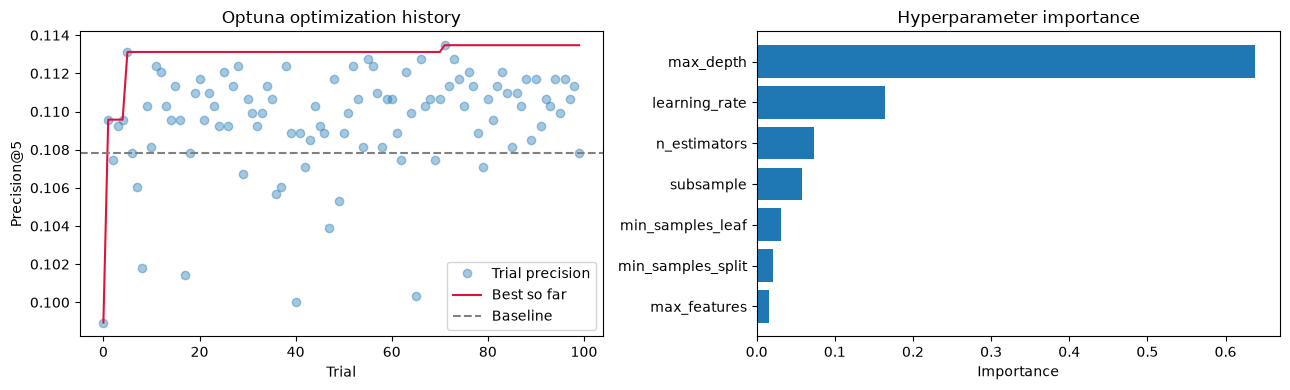

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

trial_numbers = [t.number for t in study.trials]
values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(values)

axes[0].plot(trial_numbers, values, 'o', alpha=0.4, label='Trial precision')
axes[0].plot(trial_numbers, best_so_far, color='crimson', label='Best so far')
axes[0].axhline(baseline_row['Precision'], color='gray', linestyle='--', label='Baseline')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel(f'Precision@{K}')
axes[0].set_title('Optuna optimization history')
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()))
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
